In [572]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

## Linear Regression using Normal Equations

We will use the [GasPrices](https://jgscott.github.io/STA371H_Spring2018/data/GasPrices.csv) dataset for this experiment.

In [ ]:
df = pd.read_csv("datasets\GasPrices.csv")


print(df.describe())


       Unnamed: 0          ID       Price       Pumps   Gasolines  \
count  101.000000  101.000000  101.000000  101.000000  101.000000   
mean    51.000000   51.000000    1.864257    6.950495    3.465347   
std     29.300171   29.300171    0.081515    3.925242    0.557931   
min      1.000000    1.000000    1.730000    2.000000    1.000000   
25%     26.000000   26.000000    1.790000    4.000000    3.000000   
50%     51.000000   51.000000    1.850000    6.000000    3.000000   
75%     76.000000   76.000000    1.920000    8.000000    4.000000   
max    101.000000  101.000000    2.090000   24.000000    4.000000   

            Zipcode         Income  
count    101.000000     101.000000  
mean   78730.782178   56727.217822  
std       22.054298   25868.359804  
min    78701.000000   12786.000000  
25%    78704.000000   37690.000000  
50%    78731.000000   52306.000000  
75%    78752.000000   70095.000000  
max    78759.000000  128556.000000  


In [574]:
#Grouping data
groups_by_name = df.groupby('Name')

#Average price, income and number of pumps for each group
avg_price = groups_by_name['Price'].mean()
avg_income = groups_by_name['Income'].mean()
avg_pumps = groups_by_name['Pumps'].mean()

print("Average price:\n", avg_price)
print("\nAverage income:\n", avg_income)
print("\nAverage number of pumps:\n", avg_pumps)


Average price:
 Name
7-Eleven                   1.887778
Around the Corner Store    1.940000
Chevron                    1.871818
Citgo                      1.835000
Conoco                     1.890000
Costco                     1.730000
Double R Grocery           1.790000
East 1st Grocery           1.770000
Exxon                      1.855000
Gulf                       1.788571
HEB Fuel                   1.790000
Kool Corner                1.790000
Lamar Corner Store         1.890000
Major Brand Gas            1.790000
Mobil                      1.865000
Phillips 66                1.890000
Shell                      1.883793
Signature Fuels            1.795000
Texaco                     1.912000
Valero                     1.891429
Name: Price, dtype: float64

Average income:
 Name
7-Eleven                   53432.333333
Around the Corner Store    63750.000000
Chevron                    61754.636364
Citgo                      49387.000000
Conoco                     43545.500000
Costco  

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20]),
 [Text(1, 0, '7-Eleven'),
  Text(2, 0, 'Around the Corner Store'),
  Text(3, 0, 'Chevron'),
  Text(4, 0, 'Citgo'),
  Text(5, 0, 'Conoco'),
  Text(6, 0, 'Costco'),
  Text(7, 0, 'Double R Grocery'),
  Text(8, 0, 'East 1st Grocery'),
  Text(9, 0, 'Exxon'),
  Text(10, 0, 'Gulf'),
  Text(11, 0, 'HEB Fuel'),
  Text(12, 0, 'Kool Corner'),
  Text(13, 0, 'Lamar Corner Store'),
  Text(14, 0, 'Major Brand Gas'),
  Text(15, 0, 'Mobil'),
  Text(16, 0, 'Phillips 66'),
  Text(17, 0, 'Shell'),
  Text(18, 0, 'Signature Fuels'),
  Text(19, 0, 'Texaco'),
  Text(20, 0, 'Valero')])

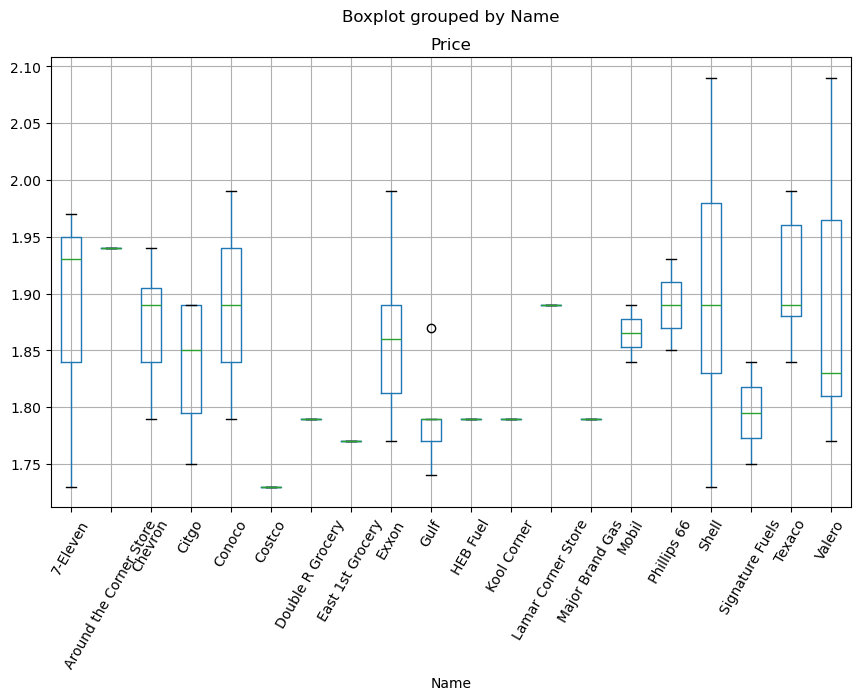

In [588]:
#Plotting boxplot by Name
df.boxplot(column='Price', by='Name', figsize=(10, 6))
plt.xticks(rotation=60)


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20]),
 [Text(1, 0, '7-Eleven'),
  Text(2, 0, 'Around the Corner Store'),
  Text(3, 0, 'Chevron'),
  Text(4, 0, 'Citgo'),
  Text(5, 0, 'Conoco'),
  Text(6, 0, 'Costco'),
  Text(7, 0, 'Double R Grocery'),
  Text(8, 0, 'East 1st Grocery'),
  Text(9, 0, 'Exxon'),
  Text(10, 0, 'Gulf'),
  Text(11, 0, 'HEB Fuel'),
  Text(12, 0, 'Kool Corner'),
  Text(13, 0, 'Lamar Corner Store'),
  Text(14, 0, 'Major Brand Gas'),
  Text(15, 0, 'Mobil'),
  Text(16, 0, 'Phillips 66'),
  Text(17, 0, 'Shell'),
  Text(18, 0, 'Signature Fuels'),
  Text(19, 0, 'Texaco'),
  Text(20, 0, 'Valero')])

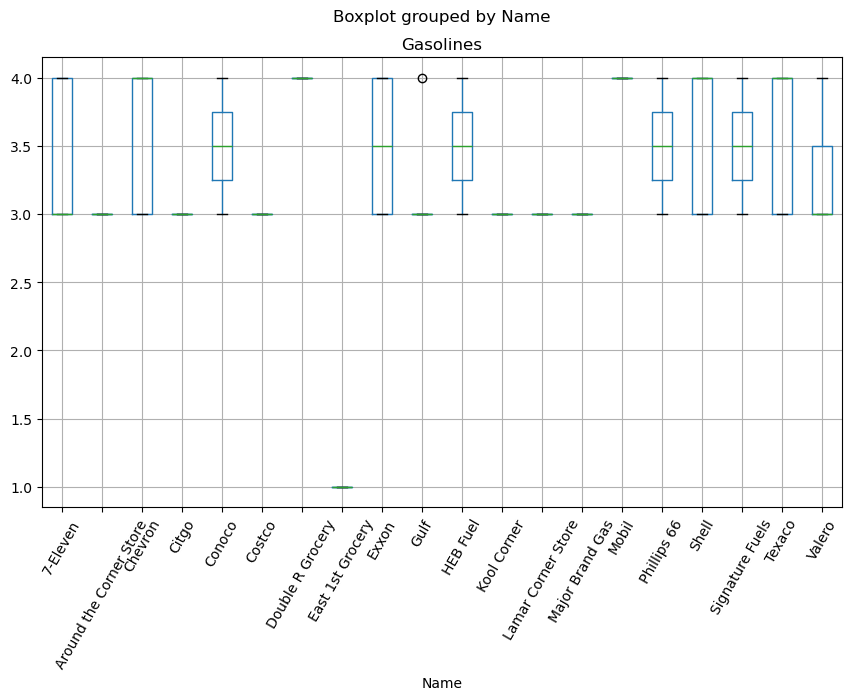

In [576]:
df.boxplot(column='Gasolines', by='Name', figsize=(10, 6))
plt.xticks(rotation=60)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20]),
 [Text(1, 0, '7-Eleven'),
  Text(2, 0, 'Around the Corner Store'),
  Text(3, 0, 'Chevron'),
  Text(4, 0, 'Citgo'),
  Text(5, 0, 'Conoco'),
  Text(6, 0, 'Costco'),
  Text(7, 0, 'Double R Grocery'),
  Text(8, 0, 'East 1st Grocery'),
  Text(9, 0, 'Exxon'),
  Text(10, 0, 'Gulf'),
  Text(11, 0, 'HEB Fuel'),
  Text(12, 0, 'Kool Corner'),
  Text(13, 0, 'Lamar Corner Store'),
  Text(14, 0, 'Major Brand Gas'),
  Text(15, 0, 'Mobil'),
  Text(16, 0, 'Phillips 66'),
  Text(17, 0, 'Shell'),
  Text(18, 0, 'Signature Fuels'),
  Text(19, 0, 'Texaco'),
  Text(20, 0, 'Valero')])

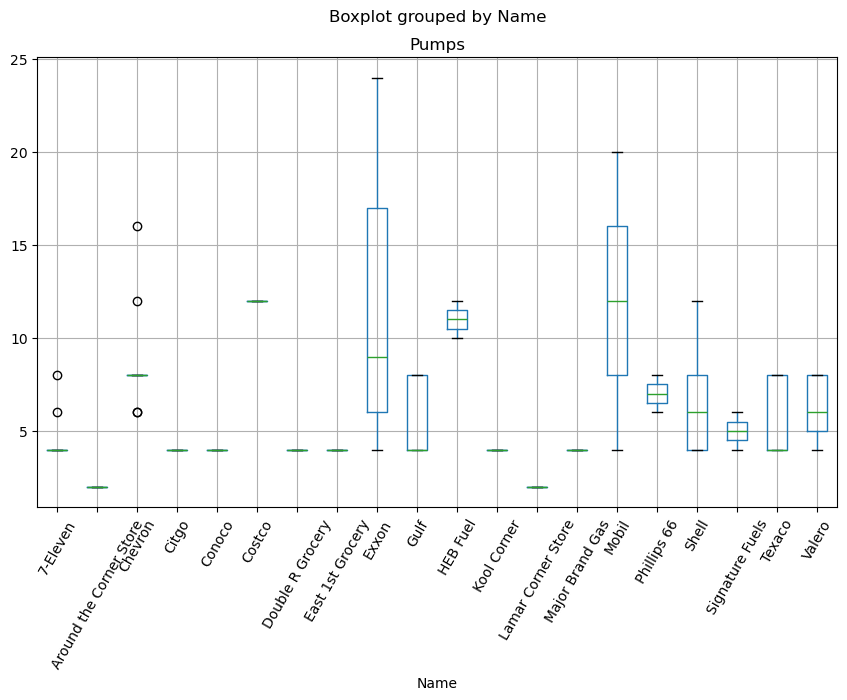

In [577]:
df.boxplot(column='Pumps', by='Name', figsize=(10, 6))
plt.xticks(rotation=60)

Using the Price and Income features of the entire dataset a linear regressor is fitted

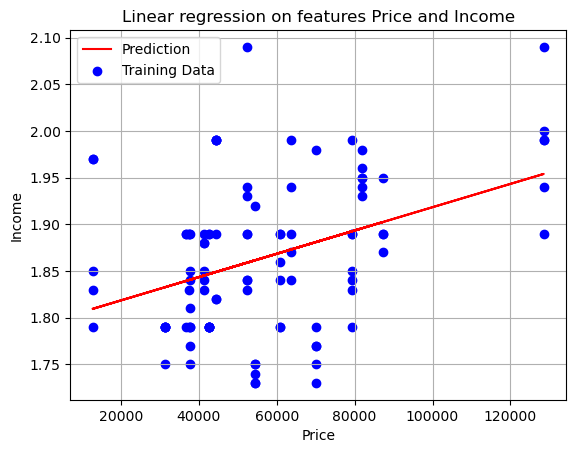

In [589]:
def lstsq_regression(data):
    #Solves for best vector [beta_0,beta_1] for the equation X @ b = y
    x = data[:,0]
    y = data[:,1]
    X = np.column_stack((np.ones(len(x)), x))
    (beta_0, beta_1), res, rank, s = np.linalg.lstsq(X, y, rcond=None)
    return beta_0, beta_1

def predict_using_slg(data_point, beta_0, beta_1):
    target_prediction = beta_0 + beta_1 * data_point
    return target_prediction


#Extract price and income colums as numpy array
data = df[['Price', 'Income']].to_numpy()

#Calculate the slope and intercept values that fits the data optimally
(beta0, beta1) = lstsq_regression(data)

#Predictions are calculated using (beta0, beta1)
predictions = np.array([[x, predict_using_slg(x, beta0, beta1)] for x in data[:,0]])


plt.plot(predictions[:,0], predictions[:,1],color='red', label='Prediction')
plt.scatter(data[:,0], data[:,1],color='blue', label='Training Data')
plt.xlabel('Price')
plt.ylabel('Income')
plt.grid(True)
plt.title('Linear regression on features Price and Income')
plt.legend()
plt.show()

Normalizing the feature income to learn (beta0, beta1) and plotting new predictions

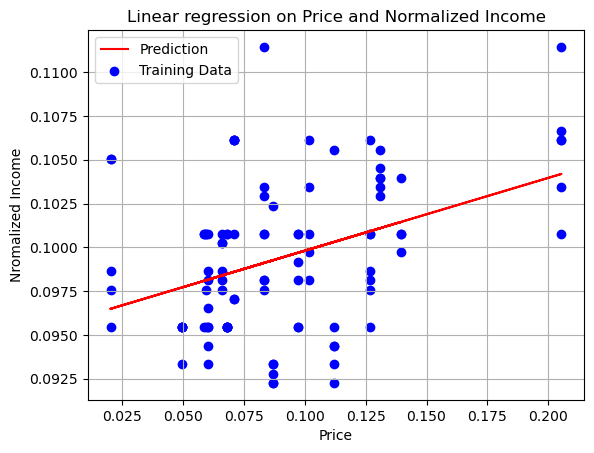

In [591]:
norm = np.linalg.norm(data[:,1])
normalized_income = data[:,1]/norm
data[:,1] = normalized_income

#Learning and predicting new values
(beta0, beta1) = lstsq_regression(data)
predictions = np.array([[x, predict_using_slg(x, beta0, beta1)] for x in data[:,0]])


plt.plot(predictions[:,0], predictions[:,1],color='red', label='Prediction')
plt.scatter(data[:,0], data[:,1],color='blue', label='Training Data')
plt.xlabel('Price')
plt.ylabel('Nromalized Income')
plt.grid(True)
plt.title('Linear regression on Price and Normalized Income')
plt.legend()
plt.show()

The predictions of both models are the same. The only difference between the two plots is the scale of the feature 'Income'.

# Linear Regression via Normal Equations

In [580]:
Xdata = pd.read_csv('GasPrices.csv')

Reason for choosing columns: 'Brand' can be an important factor as more established brands might have different pricing than less popular brands. Facilities at a gas station like the number of pumps, number of gasoline types, restaurants, car wash and having an interior increases the attractiveness of a gas station and may directly influence pricing. Gas stations next to highways may experience higher traffic which may influence price. A similar logic is also used for choosing 'Intersection'. To keep up with competitions prices would need to be adjusted, hence the reason for choosing 'Competitors'. A higher income may allow for lower prices and vice versa, hence the reason for choosing 'Income'.

Reason for dropping columns: The first two columns are obvious as they serve only for indexing purposes. The 'Zipcode' and 'Address' columns were dropped based on the assumption that price differences due to logistics are negligible, as all gas stations are located within the same city. Not much new information is available in the 'Name' column as the column 'Brand' is already considered and is more or less redundant. The column 'IntersectionStoplight' is also redundant and is dropped as well.



In [581]:
Xdata = Xdata.drop(['ID', 'Unnamed: 0','Zipcode', 'Address', 'Name', 'IntersectionStoplight'], axis=1)

#Converting Y and N values to Binary values so that regression can be carried out on it
binary_cols = ['Interior', 'Restaurant', 'CarWash', 'Highway', 'Intersection', 'Stoplight', 'Competitors']
Xdata[binary_cols] = Xdata[binary_cols].replace({'Y': 1, 'N': 0})


#One-hot encoding categorical variable 'Brand'
Xdata = pd.get_dummies(Xdata, columns=['Brand'],dtype=int)

print(Xdata.head())


   Price  Pumps  Interior  Restaurant  CarWash  Highway  Intersection  \
0   1.79      4         1           0        0        0             1   
1   1.83      4         1           0        0        0             1   
2   1.88      4         1           0        0        0             1   
3   1.88      4         1           0        1        0             1   
4   1.84      6         1           0        0        0             1   

   Stoplight  Gasolines  Competitors  Income  Brand_Chevron-Texaco  \
0          0          3            0   12786                     0   
1          0          3            0   12786                     0   
2          1          3            1   41279                     0   
3          1          4            1   41279                     1   
4          1          3            0   41279                     0   

   Brand_ExxonMobil  Brand_Other  Brand_Shell  
0                 0            0            1  
1                 0            1            

/tmp/ipykernel_20129/3567000709.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xdata[binary_cols] = Xdata[binary_cols].replace({'Y': 1, 'N': 0})


In [582]:
#Split into training and test set
Xtrain = Xdata.sample(frac=0.8, axis=0)
Xtest = Xdata.drop(Xtrain.index)

#Move Price column of each set into ytest and ytrain resp.

ytrain = Xtrain['Price'].to_numpy()
Xtrain = Xtrain.drop('Price', axis=1).to_numpy()

ytest = Xtest['Price'].to_numpy()
Xtest = Xtest.drop('Price', axis=1).to_numpy()

print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)



(81, 14) (81,)
(20, 14) (20,)


Implementations of Gaussian elimination, Cholesky and QR decomposition with which the normal equations are solved

In [583]:
def solve_using_gaussian(A, b):

    A = A.astype(float)
    b = b.astype(float)
    n = len(b)

    # Forward elimination
    for i in range(n):
        max_row = i + np.argmax(abs(A[i:, i]))
        if A[max_row, i] == 0:
            raise ValueError("Matrix is singular or nearly singular.")
        # Swap rows
        if max_row != i:
            A[[i, max_row]] = A[[max_row, i]]
            b[[i, max_row]] = b[[max_row, i]]

        # Eliminate entries below pivot
        for j in range(i + 1, n):
            factor = A[j, i] / A[i, i]
            A[j, i:] -= factor * A[i, i:]
            b[j] -= factor * b[i]

    # Back substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i + 1:], x[i + 1:])) / A[i, i]

    return x


def cholesky_decomp(A):

    n = A.shape[0]
    L = np.zeros_like(A, dtype=float)

    for i in range(n):
        for j in range(i + 1):
            s = np.dot(L[i, :j], L[j, :j])

            if i == j:
                L[i, j] = np.sqrt(A[i, i] - s)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]

    return L

def solve_using_cholesky(A,b):

    L = cholesky_decomp(A)
    # Solve L z = b
    z = np.linalg.solve(L, b)
    # Solve L.T x = z
    x = np.linalg.solve(L.T, z)
    return x

def qr_decomp(A):

    A = A.copy().astype(float)
    m, n = A.shape
    Q = np.eye(m)

    for k in range(n):
        # Extract column vector from row k to bottom
        x = A[k:, k]
        e1 = np.zeros_like(x)
        e1[0] = 1.0

        # Householder vector
        v = x + np.sign(x[0]) * np.linalg.norm(x) * e1
        v = v / np.linalg.norm(v)

        # Householder matrix
        Hk = np.eye(m)
        Hk_k = np.eye(m - k) - 2.0 * np.outer(v, v)
        Hk[k:, k:] = Hk_k

        # Apply transformation
        A = Hk @ A
        Q = Q @ Hk

    R = A
    return Q, R

def solve_using_qr(A,b):

    Q, R = qr_decomp(A)
    Qt_b = Q.T @ b
    x = np.linalg.solve(R, Qt_b)
    return x



Learn the solution vector $\beta$ for $\beta = (X^{T}X)^{-1}X^{T}y$ and perform predictions on the test set

In [584]:
def learn_linreg_normeq (Xtrain, ytrain, method):

    A = Xtrain.T @ Xtrain
    b = Xtrain.T @ ytrain

    if method == 'gaussian':
        return solve_using_gaussian(A,b)
    elif method == 'cholesky':
        return solve_using_cholesky(A,b)
    elif method == 'qr':
        return solve_using_qr(A,b)
    else:
        raise ValueError("Method must be 'gaussian' or 'cholesky' or 'qr'")

def predict_and_compare(beta, Xtest, ytest):
    #predictions
    y_hat = Xtest @ beta
    #residuals (absolute error)
    eps = np.abs(y_hat - ytest)
    eps_avg = np.mean(eps)
    rmse = np.sqrt(np.mean((ytest - y_hat) ** 2))
    return eps, eps_avg, rmse


Use the three algorithms to build the linear regression model

In [585]:
#Gaussian elimination
beta_gaussian = learn_linreg_normeq(Xtrain, ytrain, method='gaussian')
eps_gaussian, eps_avg_gaussian, rmse_gaussian = predict_and_compare(beta_gaussian, Xtest, ytest)
print("Average residual with gaussian", eps_avg_gaussian)
print("RMSE with gaussian", rmse_gaussian)

#Cholesky decomposition
beta_cholesky = learn_linreg_normeq(Xtrain, ytrain, method='cholesky')
eps_cholesky, eps_avg_cholesky, rmse_cholesky = predict_and_compare(beta_cholesky, Xtest, ytest)
print("Average residual with cholesky", eps_avg_cholesky)
print("RMSE with cholesky", rmse_cholesky)

#QR decomposition
beta_qr = learn_linreg_normeq(Xtrain, ytrain, method='qr')
eps_qr, eps_avg_qr, rmse_qr = predict_and_compare(beta_qr, Xtest, ytest)
print("Average residual with qr", eps_avg_qr)
print("RMSE with qr", rmse_qr)

Average residual with gaussian 0.04332442409973876
RMSE with gaussian 0.05643464323664618
Average residual with cholesky 0.04332442409973871
RMSE with cholesky 0.05643464323664627
Average residual with qr 0.04332442409974043
RMSE with qr 0.05643464323664499


Plotting Residual x True Price obtained through all three algorithms

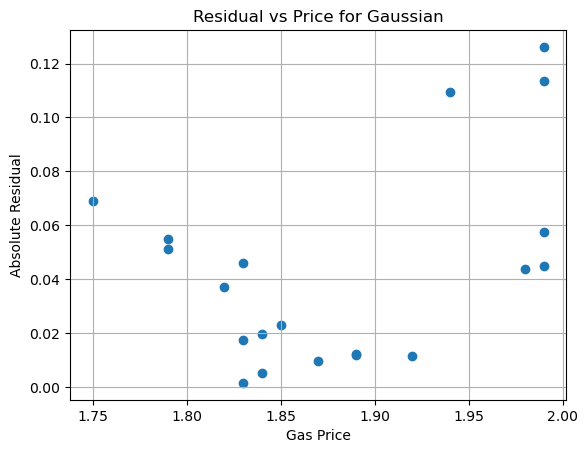

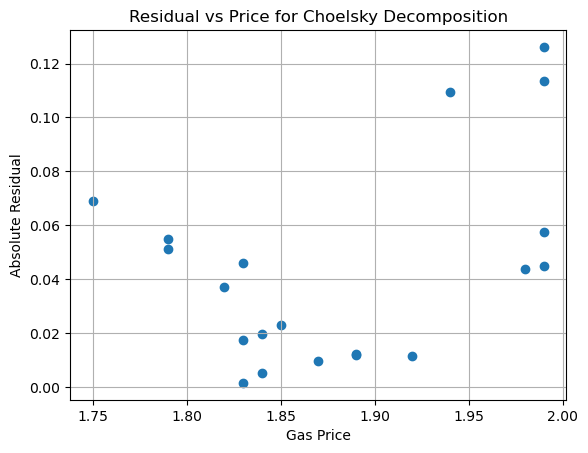

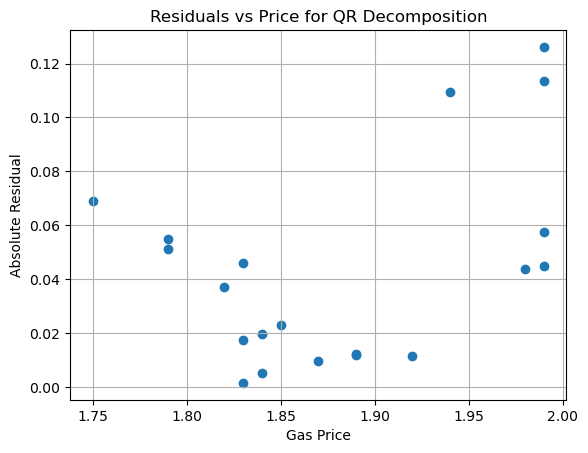

In [586]:
#Gaussian
plt.scatter(ytest, eps_gaussian)
plt.xlabel("Gas Price")
plt.ylabel("Absolute Residual")
plt.title("Residual vs Price for Gaussian")
plt.grid(True)
plt.show()

#Cholesky
plt.scatter(ytest, eps_cholesky)
plt.xlabel("Gas Price")
plt.ylabel("Absolute Residual")
plt.title("Residual vs Price for Cholesky Decomposition")
plt.grid(True)
plt.show()

#QR
plt.scatter(ytest, eps_qr)
plt.xlabel("Gas Price")
plt.ylabel("Absolute Residual")
plt.title("Residuals vs Price for QR Decomposition")
plt.grid(True)
plt.show()